In [58]:
import glob
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import os

import scanpy as sc
import seaborn as sns

from scroutines import basicu
from scroutines import powerplots

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tools.sm_exceptions import ValueWarning
from tqdm import tqdm

In [2]:
f = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/annot/gencode.vM25.genebody.bed'
df_annot = pd.read_csv(f, sep='\t', header=None)
df_annot

,0,1,2,3
0,chr1,3073253,3074322,4933401J01Rik
1,chr1,3102016,3102125,Gm26206
2,chr1,3205901,3671498,Xkr4
3,chr1,3252757,3253236,Gm18956
4,chr1,3365731,3368549,Gm37180
...,...,...,...,...
55396,chrM,13552,14070,mt-Nd6
55397,chrM,14071,14139,mt-Te
55398,chrM,14145,15288,mt-Cytb
55399,chrM,15289,15355,mt-Tt


In [3]:
ddir = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/results_nrdr_lmm/'
!ls $ddir

NRDR_DEGs_LMM_P12_L23_ALL_v2.csv     NRDR_DEGs_LMM_P21_L23_ALL.csv
NRDR_DEGs_LMM_P12_L23_A_v2.csv	     NRDR_DEGs_LMM_P21_L23_B.csv
NRDR_DEGs_LMM_P12_L23_B_v2.csv	     NRDR_DEGs_LMM_P21_L23_C.csv
NRDR_DEGs_LMM_P12_L23_C_v2.csv	     NRDR_DEGs_LMM_P21_L23_v1.csv
NRDR_DEGs_LMM_P14_L23_ALL_v2.csv     NRDR_DEGs_LMM_P21_L4_v1.csv
NRDR_DEGs_LMM_P14_L23_A_v2.csv	     NRDR_DEGs_LMM_P21_L56IT.csv
NRDR_DEGs_LMM_P14_L23_B_v2.csv	     NRDR_DEGs_LMM_P21_L5IT_v1.csv
NRDR_DEGs_LMM_P14_L23_C_v2.csv	     NRDR_DEGs_LMM_P21_L5NP_v1.csv
NRDR_DEGs_LMM_P17_L23_ALL_v2.csv     NRDR_DEGs_LMM_P21_L5PT_v1.csv
NRDR_DEGs_LMM_P17_L23_A_v2.csv	     NRDR_DEGs_LMM_P21_L6CT_v1.csv
NRDR_DEGs_LMM_P17_L23_B_v2.csv	     NRDR_DEGs_LMM_P21_L6IT_v1.csv
NRDR_DEGs_LMM_P17_L23_C_v2.csv	     NRDR_DEGs_LMM_P21_Lamp5_v1.csv
NRDR_DEGs_LMM_P21_Astro_d251027.csv  NRDR_DEGs_LMM_P21_Micro_v1.csv
NRDR_DEGs_LMM_P21_Astro_v1.csv	     NRDR_DEGs_LMM_P21_OD_v1.csv
NRDR_DEGs_LMM_P21_bigmodel.h5ad      NRDR_DEGs_LMM_P21_OPC_v1.csv
NRDR_DEGs_LMM_P

In [4]:
res_df_sig = {}

filename = os.path.join(ddir, 'NRDR_DEGs_LMM_P21_Astro_d251027.csv')
subclass = filename.split('_')[-2]
df = pd.read_csv(filename, index_col=0)
df['max_cp10k'] = np.max(df.iloc[:,5:], axis=1)
x = df['log2fc']
y = df['qval']
z = df['max_cp10k']
converged = df['converged']

x_th = np.log2(2)
y_th = 0.05
z_th = 0.1

cond_sig = np.all([np.abs(x) > x_th, y < y_th, z > z_th, converged], axis=0)

print(subclass, np.sum(cond_sig))
df_sig = df[cond_sig].copy().sort_values('qval')
res_df_sig[subclass] = df_sig


Astro 68


In [5]:
df

,gene,log2fc,pval,qval,converged,P21DRa,P21DRb,P21a,P21b,max_cp10k
0,Xkr4,0.611364,0.701645,0.848574,True,0.292708,0.242097,0.237188,0.108264,0.292708
1,Mrpl15,-0.397540,0.000580,0.017729,False,0.233444,0.177964,0.263058,0.300463,0.300463
2,Tcea1,0.027188,0.272805,0.588903,True,0.730683,0.875147,0.782632,0.765016,0.875147
3,Rgs20,-0.472641,0.001658,0.037255,True,11.322722,13.908487,16.180243,18.213694,18.213694
4,Atp6v1h,-0.174327,0.248795,0.572482,True,1.025575,1.013590,1.279131,1.018866,1.279131
...,...,...,...,...,...,...,...,...,...,...
10333,Zfp950,-0.285825,0.066254,0.333221,True,1.017038,1.264671,1.334499,1.395384,1.395384
10334,Vamp7,0.489344,0.583142,0.779180,False,0.249058,0.209138,0.162012,0.164169,0.249058
10335,Tmlhe,-0.020622,0.149963,0.469225,True,0.575418,0.404512,0.534983,0.491310,0.575418
10336,AC149090.1,-0.071783,0.656524,0.822494,True,1.425211,0.983141,0.612102,2.055221,2.055221


In [6]:
df_sig

,gene,log2fc,pval,qval,converged,P21DRa,P21DRb,P21a,P21b,max_cp10k
9254,Pde10a,-2.632531,1.266481e-207,1.309288e-204,True,1.162674,0.964373,5.924126,7.661581,7.661581
5707,Junb,-1.789376,3.320058e-25,2.640213e-22,True,0.278781,0.147307,0.761935,0.850260,0.850260
2993,Cyp51,-1.041883,3.360247e-20,2.315882e-17,True,0.973399,0.794653,1.792478,1.944579,1.944579
10204,Ppp1r3c,-1.002241,6.206419e-17,3.774233e-14,True,0.947311,1.003591,1.619775,2.308276,2.308276
9370,Dusp1,-1.292831,1.827260e-12,8.213137e-10,True,0.259120,0.276388,0.509132,0.834065,0.834065
...,...,...,...,...,...,...,...,...,...,...
998,Syt13,1.223900,2.308027e-03,4.562215e-02,True,0.297109,0.180107,0.098365,0.104330,0.297109
5856,Tmem231,-1.132021,2.378428e-03,4.587348e-02,True,0.027686,0.045095,0.074721,0.102153,0.102153
1474,Pcsk1n,1.122183,2.419547e-03,4.649309e-02,True,4.105707,3.278501,1.114667,2.379994,4.105707
593,Rrp15,-1.374519,2.445771e-03,4.673639e-02,True,0.030752,0.086839,0.136329,0.173625,0.173625


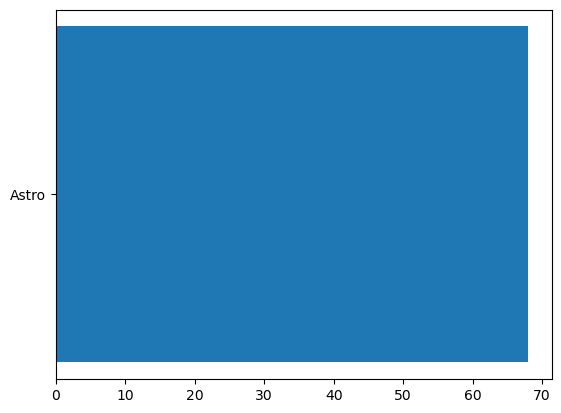

In [7]:
labels = []
nums = []
for subclass, df_sig in res_df_sig.items():
    labels.append(subclass)
    nums.append(len(df_sig))
    
fig, ax = plt.subplots()
ax.barh(np.arange(len(nums)), nums)
ax.set_yticks(np.arange(len(nums)))
ax.set_yticklabels(labels)
plt.show()

In [59]:
df.set_index('gene').loc['Rfx4']

log2fc      -0.697471
pval         0.000147
qval         0.006877
converged        True
P21DRa        2.74997
P21DRb       3.072649
P21a         4.830879
P21b         4.513134
max_cp10k    4.830879
Name: Rfx4, dtype: object

In [62]:
mean_gexp = df.set_index('gene').loc['Rfx4', ['P21a', 'P21b', 'P21DRa', 'P21DRb']]

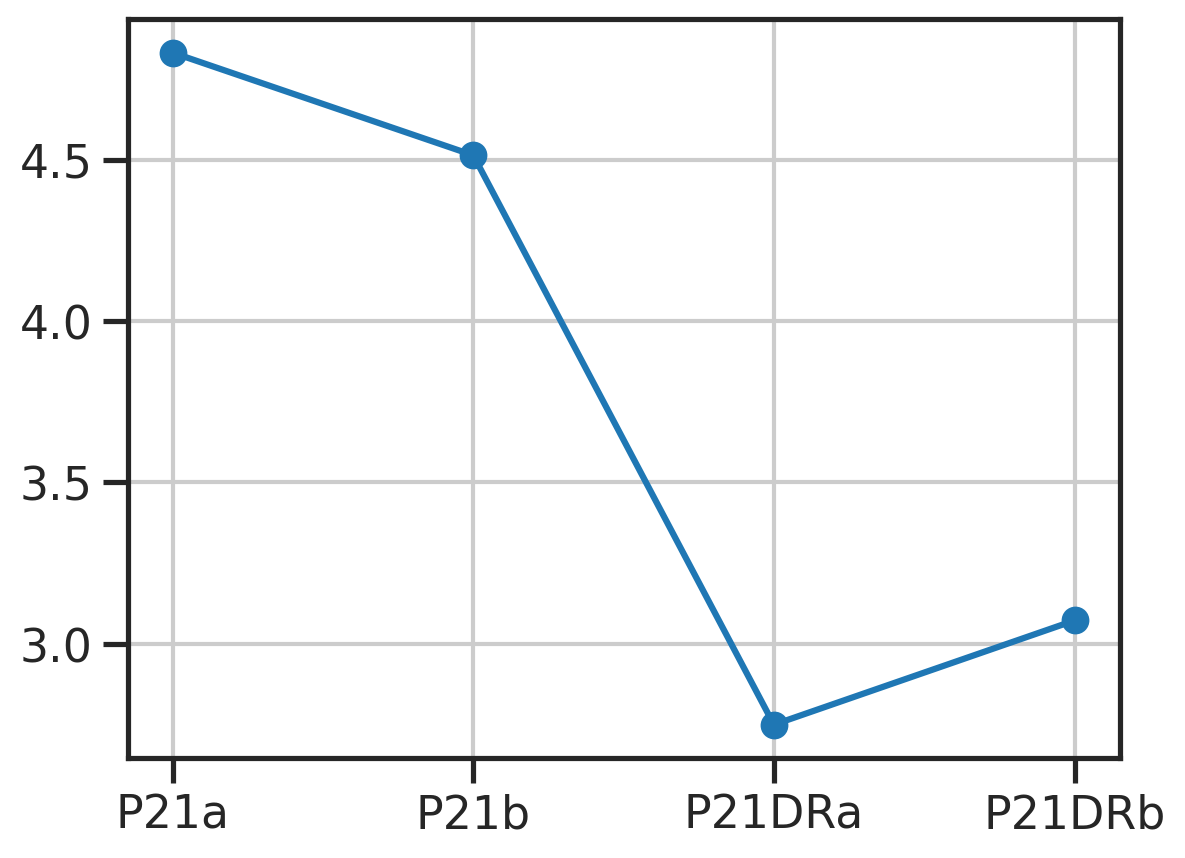

In [63]:
plt.plot(mean_gexp, '-o')

# cell level data

In [11]:
adata = sc.read("/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/superdupermegaRNA_hasraw_multiome_P21NRDR.h5ad")
adata.X = adata.raw.X
adata

AnnData object with n_obs × n_vars = 31039 × 16572
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden'
    var: 'feature_types'

In [12]:
# remove mitocondria genes
adata = adata[:,~adata.var.index.str.contains(r'^mt-')]

# remove sex genes
sex_genes = ["Xist", "Uty", "Eif2s3y", "Kdm5d", "Ddx3y"]
adata = adata[:,[g for g in adata.var.index if g not in sex_genes]]

# filter genes
cond = np.ravel((adata.X>0).sum(axis=0)) > 10 # expressed in more than 10 cells
adata = adata[:,cond].copy()
# genes = adata.var.index.values

adata

AnnData object with n_obs × n_vars = 31039 × 16547
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden'
    var: 'feature_types'

In [97]:
tag = 'd251027'
subclass = 'Astro'
time = 'P21'
exp_conds = [time, time+'DR']
# subclass  = 'L2/3'
subclass_cure = subclass.replace('/', '')
offset = 1e-2
scale = 1e4

adata = adata[(adata.obs['Age'].isin(exp_conds)) & (adata.obs['Subclass']==subclass)]
mat = np.array(adata.X.todense())/adata.obs['total_counts'].values.reshape(-1,1)*scale
adata.layers['cp10k'] = mat
adata.layers['log2cp10k'] = np.log2(1+mat)
adata

AnnData object with n_obs × n_vars = 2142 × 16547
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden'
    var: 'feature_types'
    layers: 'cp10k', 'log2cp10k'

In [137]:
def plot_one_gene(gene):
    """
    """
    sample_orders = ['P21a', 'P21b', 'P21DRa', 'P21DRb']
    palette = {'P21': 'C1', 'P21DR': 'gray'}

    dfplot = adata.obs[['Age', 'Sample', 'Type']].copy()
    dfplot[gene] = np.array(adata[:,gene].layers['log2cp10k']).reshape(-1,)
    stats = df.set_index('gene').loc[gene]

    fig, ax = plt.subplots(figsize=(4,5))
    sns.violinplot(data=dfplot, x='Sample', hue='Age', palette=palette,
                   order=sample_orders, 
                   dodge=False, y=gene, 
                   cut=0, 
                   ax=ax)
    ax.set_title(f'q={stats.qval:.2g}, log2FC={stats.log2fc:.2g}, conv {stats.converged}')
    # ax.scatter(np.arange(len(sample_orders)), stats.loc[sample_orders], color='k', marker='x', zorder=2, linewidths=1)
    ax.legend(bbox_to_anchor=(1,1))
    plt.show()
    
def plot_one_gene_ax(gene, ax):
    """
    """
    sample_orders = ['P21a', 'P21b', 'P21DRa', 'P21DRb']
    palette = {'P21': 'C1', 'P21DR': 'gray'}

    dfplot = adata.obs[['Age', 'Sample', 'Type']].copy()
    dfplot[gene] = np.array(adata[:,gene].layers['log2cp10k']).reshape(-1,)
    stats = df.set_index('gene').loc[gene]

    sns.violinplot(data=dfplot, x='Sample', hue='Age', palette=palette,
                   order=sample_orders, 
                   # legend=False,
                   dodge=False, y=gene, 
                   cut=0, 
                   ax=ax)
    ax.legend([])
    ax.set_title(f'q={stats.qval:.2g}, lfc={stats.log2fc:.2g}, conv {stats.converged}', fontsize=12)
    # ax.scatter(np.arange(len(sample_orders)), stats.loc[sample_orders], color='k', marker='x', zorder=2, linewidths=1)

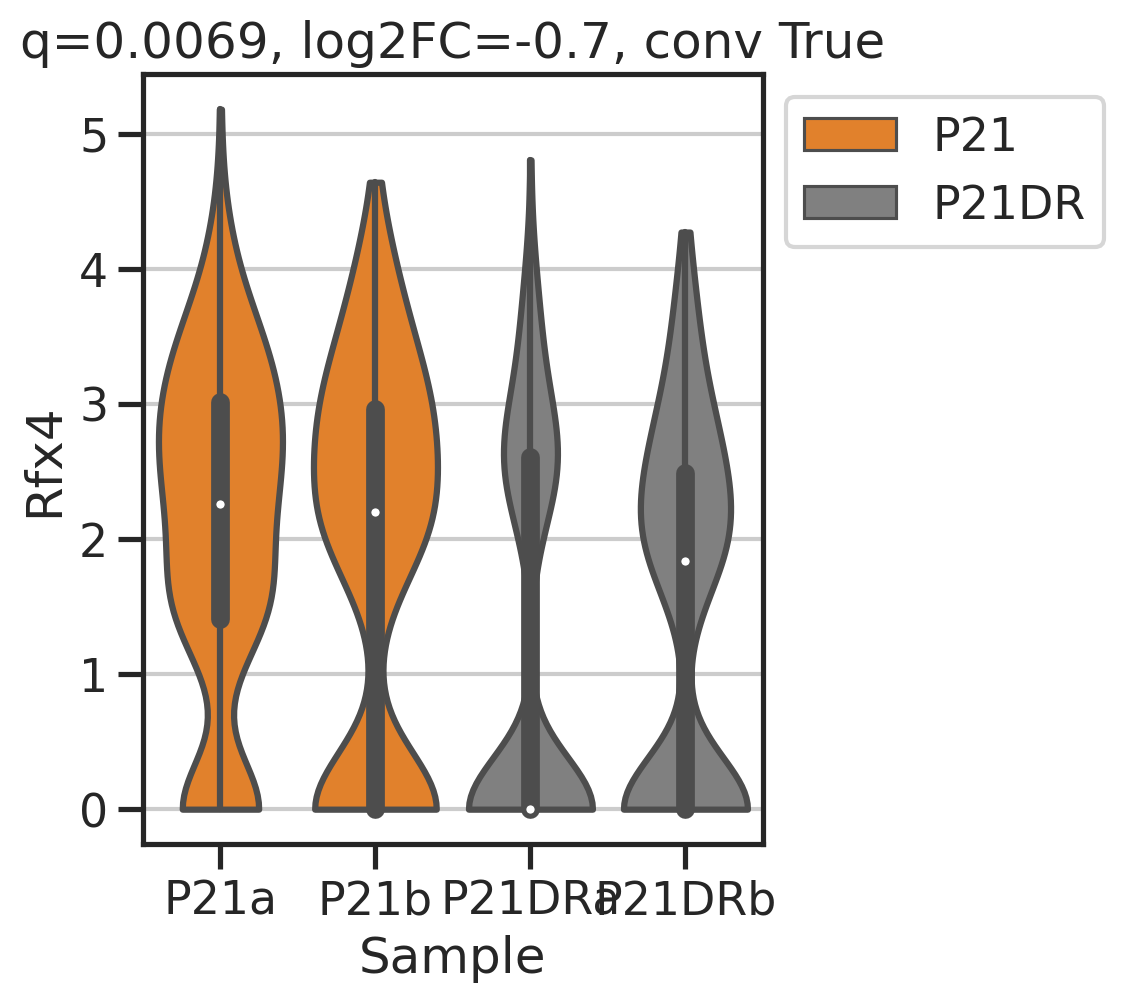

In [130]:
gene = 'Rfx4'
plot_one_gene(gene)

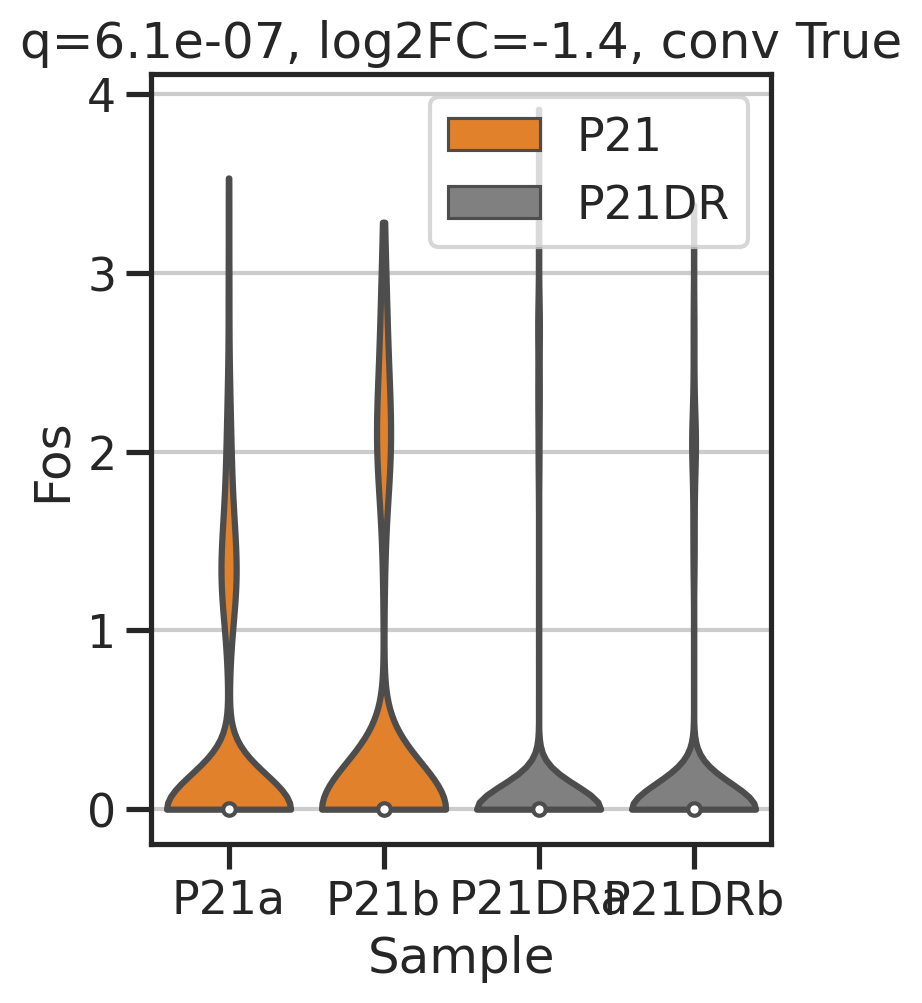

In [131]:
gene = 'Fos'
plot_one_gene(gene)

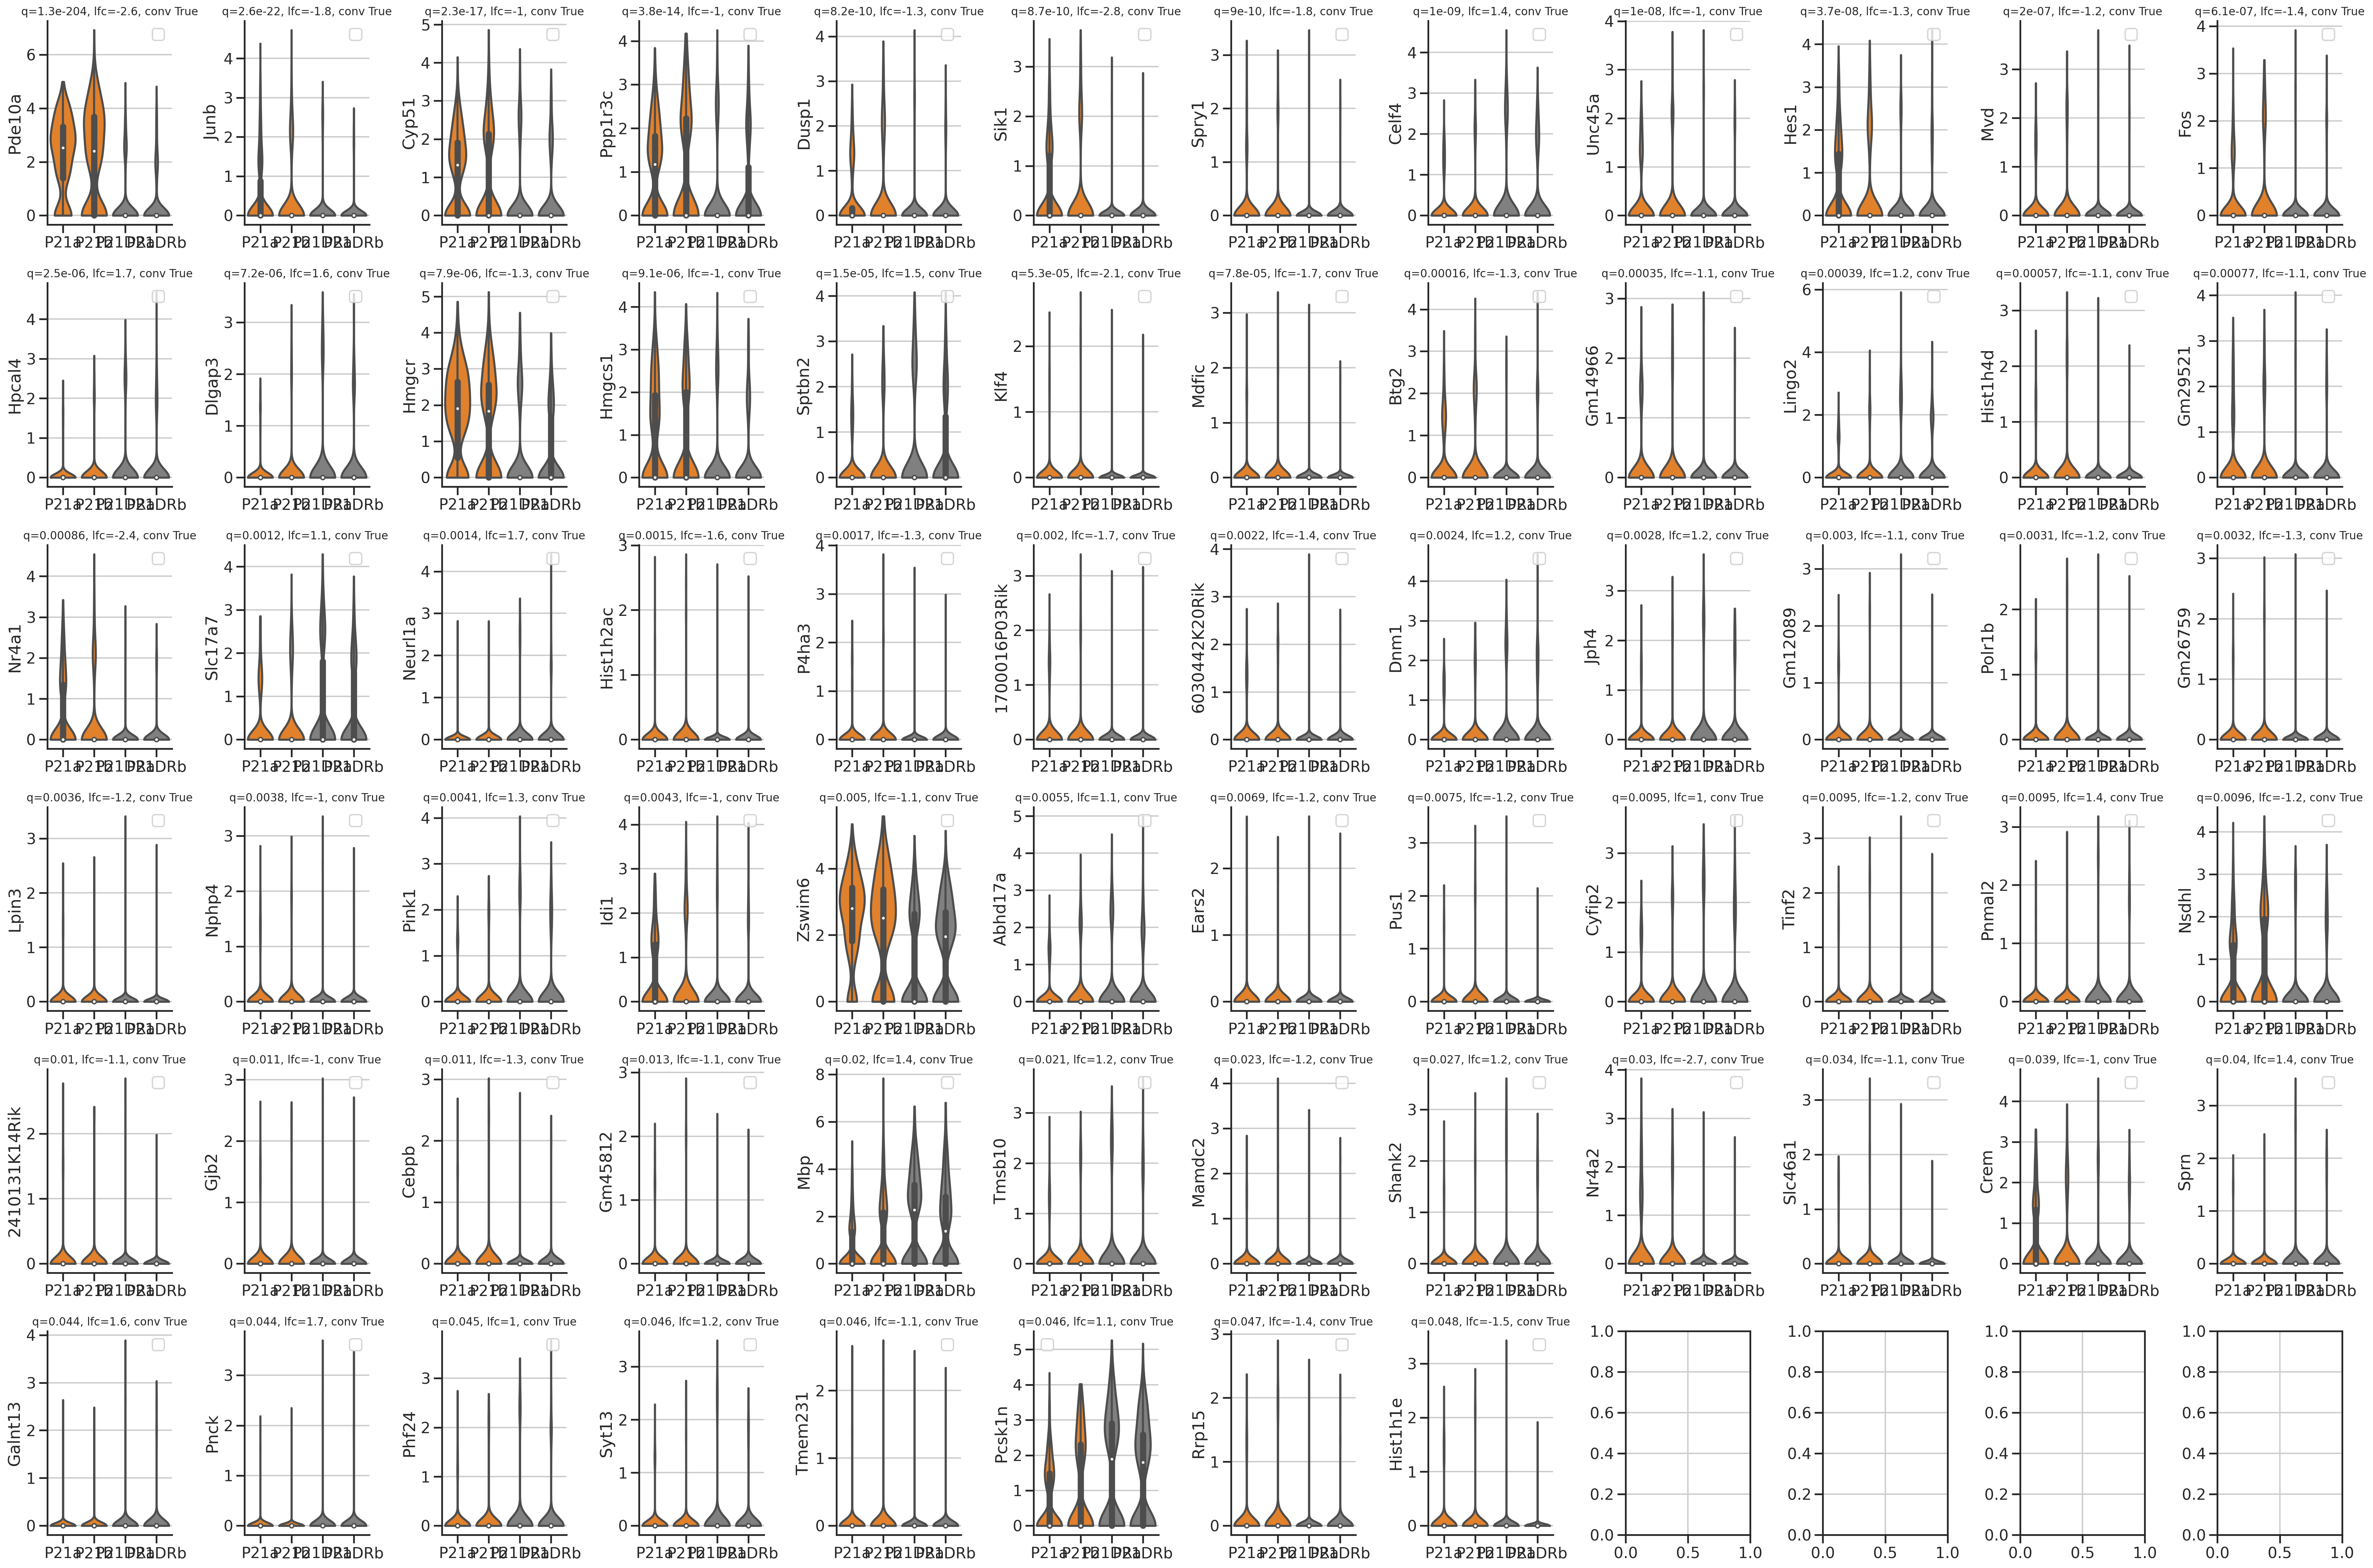

In [140]:
gene_list = df_sig['gene'] #[:10]
n = len(gene_list)
nx = 12
ny = int((n+nx-1)/nx)

fig, axs = plt.subplots(ny, nx, figsize=(3*nx,4*ny))
for i, gene in enumerate(gene_list):
    ax = axs.flat[i]
    plot_one_gene_ax(gene, ax)
    ax.set_xlabel('')
    sns.despine(ax=ax)
fig.tight_layout()